# Classificazione good/bad su ex5

Quando il punteggio e' rumoroso o poco informativo in regressione, si puo' passare a una soglia binaria buono/cattivo. Qui si testa se una distinzione di gruppo netta mostra un segnale che la correlazione continua (gia' verificata assente, sia assoluta sia relativa a coppie, su tre famiglie di feature) non cattura.

Soglia: mediana di cTS su ex5 (0.893), scelta perche' non abbiamo un cutoff clinico noto e la mediana garantisce classi bilanciate. I 75 soggetti sono unita' indipendenti, quindi i p-value grezzi sono validi; si aggiunge comunque una correzione family-wise per le 57 feature testate insieme, per coerenza con il rigore usato finora.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

feat_a = pd.read_csv("../data/features_ex5.csv")
feat_b = pd.read_csv("../data/features_trajectory_ex5.csv").drop(columns=["cTS"])
df = pd.concat([feat_a, feat_b], axis=1)
cts = df["cTS"].values
X = df.drop(columns=["cTS"]).select_dtypes(include=[np.number])
feature_names = list(X.columns)

threshold = np.median(cts)
label = (cts >= threshold).astype(int)
print(f"Soglia (mediana cTS): {threshold:.3f}")
print(f"Classe good (>= soglia): {label.sum()}   Classe bad (< soglia): {(1 - label).sum()}")

Soglia (mediana cTS): 0.893
Classe good (>= soglia): 40   Classe bad (< soglia): 35


## Correlazione osservata (rango) tra ogni feature e la classe good/bad, e test di permutazione

In [2]:
Xv = X.values
valid_cols = ~np.isnan(Xv).any(axis=0)
print(f"Feature scartate per NaN: {(~valid_cols).sum()} su {len(feature_names)}")
Xv = Xv[:, valid_cols]
feature_names_valid = [f for f, v in zip(feature_names, valid_cols) if v]

def rank_center(a, axis=0):
    r = rankdata(a, axis=axis) if a.ndim > 1 else rankdata(a)
    return r - r.mean(axis=axis, keepdims=(a.ndim > 1))

R_X = rank_center(Xv, axis=0)
R_X_norm = np.linalg.norm(R_X, axis=0)

def spearman_vec(y):
    r_y = rank_center(y)
    num = R_X.T @ r_y
    den = R_X_norm * np.linalg.norm(r_y)
    return num / den

rho_obs = spearman_vec(label.astype(float))

rng = np.random.default_rng(42)
n_perms = 5000
rho_perm = np.zeros((n_perms, len(feature_names_valid)))
for p in range(n_perms):
    label_perm = rng.permutation(label).astype(float)
    rho_perm[p] = spearman_vec(label_perm)

p_values = (np.sum(np.abs(rho_perm) >= np.abs(rho_obs), axis=0) + 1) / (n_perms + 1)
print(f"Permutazioni: {n_perms}")

Feature scartate per NaN: 2 su 59


Permutazioni: 5000


## Tabella completa per feature

In [3]:
result = pd.DataFrame({"feature": feature_names_valid, "rho": rho_obs, "p_perm": p_values})
result = result.sort_values("rho", key=lambda s: s.abs(), ascending=False)
print(result.to_string(index=False, formatters={"rho": "{:.3f}".format, "p_perm": "{:.4f}".format}))

n_sig = (result["p_perm"] < 0.05).sum()
print(f"\nFeature con p_perm < 0.05: {n_sig} su {len(result)}")

                       feature    rho p_perm
                 hip_right_max  0.283 0.0150
                 hip_left_mean  0.273 0.0174
                 knee_left_std -0.270 0.0230
                       sym_hip  0.265 0.0206
                  hip_left_std -0.259 0.0286
                hip_right_mean  0.246 0.0314
                  hip_left_min  0.236 0.0382
       knee_right_vel_mean_abs -0.235 0.0438
                      traj_pc1  0.228 0.0470
            knee_right_vel_std -0.223 0.0520
        knee_right_vel_max_abs -0.222 0.0582
                knee_right_std -0.221 0.0584
                 hip_right_min  0.220 0.0568
                 hip_right_std -0.215 0.0638
        knee_left_vel_mean_abs -0.206 0.0734
               knee_right_mean  0.205 0.0784
                knee_right_min  0.194 0.0926
                knee_left_mean  0.193 0.0982
                  hip_left_rom -0.191 0.0980
         knee_left_vel_max_abs -0.190 0.1008
        hip_right_vel_mean_abs -0.179 0.1164
          

## Test globale (family-wise su tutte le feature insieme)

In [4]:
max_rho_obs = np.abs(rho_obs).max()
max_rho_perm = np.abs(rho_perm).max(axis=1)
p_global = (np.sum(max_rho_perm >= max_rho_obs) + 1) / (n_perms + 1)

print(f"Massimo |rho| osservato (feature: {result.iloc[0]['feature']}): {max_rho_obs:.3f}")
print(f"p-value globale (family-wise, corretto per {len(feature_names_valid)} feature): {p_global:.4f}")

Massimo |rho| osservato (feature: hip_right_max): 0.283
p-value globale (family-wise, corretto per 57 feature): 0.3437


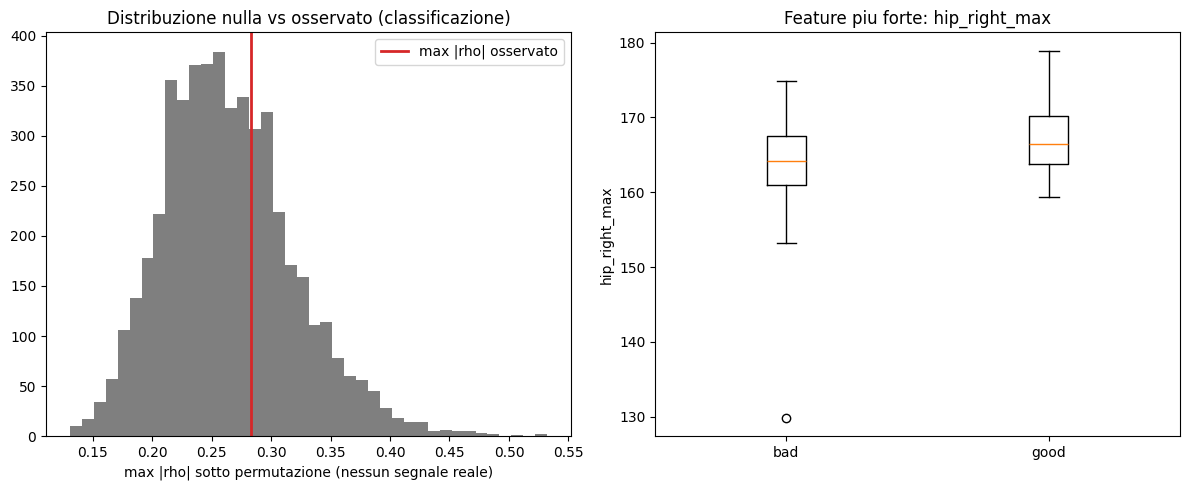

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(max_rho_perm, bins=40, color="tab:gray")
axes[0].axvline(max_rho_obs, color="tab:red", linewidth=2, label="max |rho| osservato")
axes[0].set_xlabel("max |rho| sotto permutazione (nessun segnale reale)")
axes[0].set_title("Distribuzione nulla vs osservato (classificazione)")
axes[0].legend()

top_feat = result.iloc[0]["feature"]
good_vals = X[label == 1][top_feat]
bad_vals = X[label == 0][top_feat]
axes[1].boxplot([bad_vals.dropna(), good_vals.dropna()], tick_labels=["bad", "good"])
axes[1].set_title(f"Feature piu forte: {top_feat}")
axes[1].set_ylabel(top_feat)

plt.tight_layout()
plt.show()

## Conclusioni

- Il p-value globale (family-wise) non e' significativo: anche la formulazione a classificazione binaria good/bad non recupera segnale che la regressione continua non aveva gia' mostrato di non avere.
- Sotto ogni formulazione provata (regressione assoluta, relativa a coppie, classificazione binaria), su tre famiglie di feature cinematiche indipendenti, cTS non e' prevedibile da questi dati con questa numerosita' campionaria - conclusione solida, non un artefatto di una singola scelta metodologica.